In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Define f_T(t)
# -----------------------------
def f_T(t):
    """
    Prescribed function f_T(t) = n_T(t)/n_tot.
    Example: exponential rise from 0 to 0.5.
    """
    return 0.5 * (1 - np.exp(-t/(3600*24*365*100)))   # shape (n_times,)

# -----------------------------
# Parameter grid builder
# -----------------------------
def build_param_grid(param_ranges):
    """
    Build a parameter grid (Cartesian product) from dictionary of arrays.
    Returns dictionary of arrays, each shaped (n_combinations,).
    """
    keys = list(param_ranges.keys())
    values = list(param_ranges.values())
    combos = list(itertools.product(*values))
    combos = np.array(combos)
    return {k: combos[:, i] for i, k in enumerate(keys)}

# -----------------------------
# Main solver
# -----------------------------
def evaluate_system(times, param_grid):
    """
    Evaluate n_T(t) and inventory source terms at given times.
    No ODE integration, purely algebraic using f_T(t).
    """
    n_times = len(times)
    n_cases = len(next(iter(param_grid.values())))  # number of parameter combinations

    # Compute f_T(t) for all times
    fT = f_T(times)   # shape (n_times,)
    
    # Compute n_T(t) for all parameter sets
    n_T = fT[None, :] * param_grid["n_tot"][:, None]  # shape (n_cases, n_times)

    # Preallocate dictionaries for results
    results = {"n_T": n_T}

    # Extract parameters (all shape (n_cases,))
    tau_ofc   = param_grid["tau_ofc"]
    tau_ifc   = param_grid["tau_ifc"]
    TBR_DT    = param_grid["TBR_DT"]
    TBR_DDn   = param_grid["TBR_DDn"]
    V_p       = param_grid["V_p"]
    tau_pT    = param_grid["tau_pT"]
    sigmav_DT = param_grid["sigmav_DT"]
    sigmav_DDp= param_grid["sigmav_DDp"]
    n_tot     = param_grid["n_tot"]
    lam       = param_grid.get("lambda", np.zeros_like(n_tot))  # optional λ

    # Expand to shape (n_cases, n_times) by broadcasting
    Vp   = V_p[:, None]
    TBRdt= TBR_DT[:, None]
    TBRdd= TBR_DDn[:, None]
    svDT = sigmav_DT[:, None]
    svDD = sigmav_DDp[:, None]
    taupT= tau_pT[:, None]
    tauO = tau_ofc[:, None]
    tauI = tau_ifc[:, None]
    lam_ = lam[:, None]
    ntot = n_tot[:, None]

    # compute fusion power
    # DT fusion: P_fus_DT = n_T*n_D * <σv>_DT * V_p * E_fus_DT
    # DD fusion: P_fus_DDp = n_D*n_D/2 * <σv>_DD * V_p * E_fus_DD
    # Use E_fus_DT = 17.6 MeV, E_fus_DDp = 3.5 MeV (in Joules)
    
    # Convert MeV to Joules (1 MeV = 1.602176e-13 J)
    E_fus_DT = 17.6 * 1.602176e-13  # Joules
    E_fus_DD = 3.5 * 1.602176e-13   # Joules
    
    # Calculate n_D (deuterium density)
    n_D = ntot - n_T  # shape (n_cases, n_times)
    
    # DT fusion power
    P_fus_DT = n_T * n_D * svDT * Vp * E_fus_DT  # shape (n_cases, n_times)
    
    # DD fusion power (n_D^2/2 because identical particles)
    P_fus_DD = n_D**2 / 2 * svDD * Vp * E_fus_DD  # shape (n_cases, n_times)
    
    # Total fusion power
    P_fus_total = P_fus_DT + P_fus_DD
    
    # Store in results
    results["P_fus_DT"] = P_fus_DT
    results["P_fus_DD"] = P_fus_DD
    results["P_fus_total"] = P_fus_total

        # Alternative: Fully vectorized approach using cumulative integration
    # This assumes linear interpolation of source terms between time points
    
    # Time step
    if n_times > 1:
        dt = times[1] - times[0]
        
        # Compute all source terms for all times
        # Breeding source for OFC
        S_ofc_breeding = (TBRdt*svDT*Vp * n_T * (ntot - n_T) + 
                         TBRdd*svDD*Vp/2 * (ntot - n_T)**2)  # shape (n_cases, n_times)
        
        # Pumping source for IFC  
        S_ifc_pumping = Vp/taupT * n_T  # shape (n_cases, n_times)
        
        # Loss terms (these will be handled in the integration)
        
        # Initialize arrays
        I_ofc = np.zeros((n_cases, n_times))
        I_ifc = np.zeros((n_cases, n_times))
        I_st = np.ones((n_cases, n_times))
        
        # Vectorized forward Euler integration
        for t_idx in range(1, n_times):
            # OFC inventory
            loss_ofc = I_ofc[:, t_idx-1] * (1/tauO[:, 0] + lam_[:, 0])
            I_ofc[:, t_idx] = I_ofc[:, t_idx-1] + dt * (S_ofc_breeding[:, t_idx-1] - loss_ofc)
            
            # IFC inventory
            transfer_from_ofc = I_ofc[:, t_idx-1] / tauO[:, 0]
            loss_ifc = I_ifc[:, t_idx-1] * (1/tauI[:, 0] + lam_[:, 0])
            I_ifc[:, t_idx] = I_ifc[:, t_idx-1] + dt * (transfer_from_ofc + S_ifc_pumping[:, t_idx-1] - loss_ifc)
            
            # Storage inventory
            transfer_from_ifc = I_ifc[:, t_idx-1] / tauI[:, 0]
            injection_rate = n_T[:, t_idx-1] * svDT[:, 0] * (ntot[:, 0] - n_T[:, t_idx-1]) * Vp[:, 0]
            loss_st = I_st[:, t_idx-1] * lam_[:, 0]
            I_st[:, t_idx] = I_st[:, t_idx-1] + dt * (transfer_from_ifc - injection_rate - loss_st)
        
    
    # Store results
    results["I_ofc"] = I_ofc
    results["I_ifc"] = I_ifc
    results["I_st"] = I_st
    results["negative_inventory"] = (I_ofc < 0) | (I_ifc < 0) | (I_st < 0)
    
    return results


In [3]:
# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Define parameter ranges
    n_param = 2
    param_ranges = {
        "tau_ofc":   np.linspace(1, 2, n_param)*3600*24,
        "tau_ifc":   np.linspace(2, 4, n_param)*3600*24,
        "TBR_DT":    np.linspace(1.0, 1.5, n_param),
        "TBR_DDn":   np.linspace(0.5, 1.1, n_param),
        "V_p":       np.linspace(100, 200, n_param),
        "tau_pT":    np.linspace(0.1, 2, n_param),
        "sigmav_DT": np.linspace(1e-25, 1e-23, n_param),
        "sigmav_DDp":np.linspace(1e-27, 1e-25,n_param),
        "n_tot":     np.linspace(1e20, 2e20, n_param),
        "lambda":    np.linspace(1.7840546192929202e-09, 1.7840546192929202e-09, n_param),
    }

    # Build grid of parameter combinations
    grid = build_param_grid(param_ranges)

    # Time points
    times = np.linspace(0, 100, 100)

    # Evaluate system
    results = evaluate_system(times, grid)

/tmp/ipykernel_107832/2688762616.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_107832/2688762616.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_107832/2688762616.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_107832/2688762616.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_107832/2688762616.py:58: UserWarning: No artists with labels found to put in legend. 

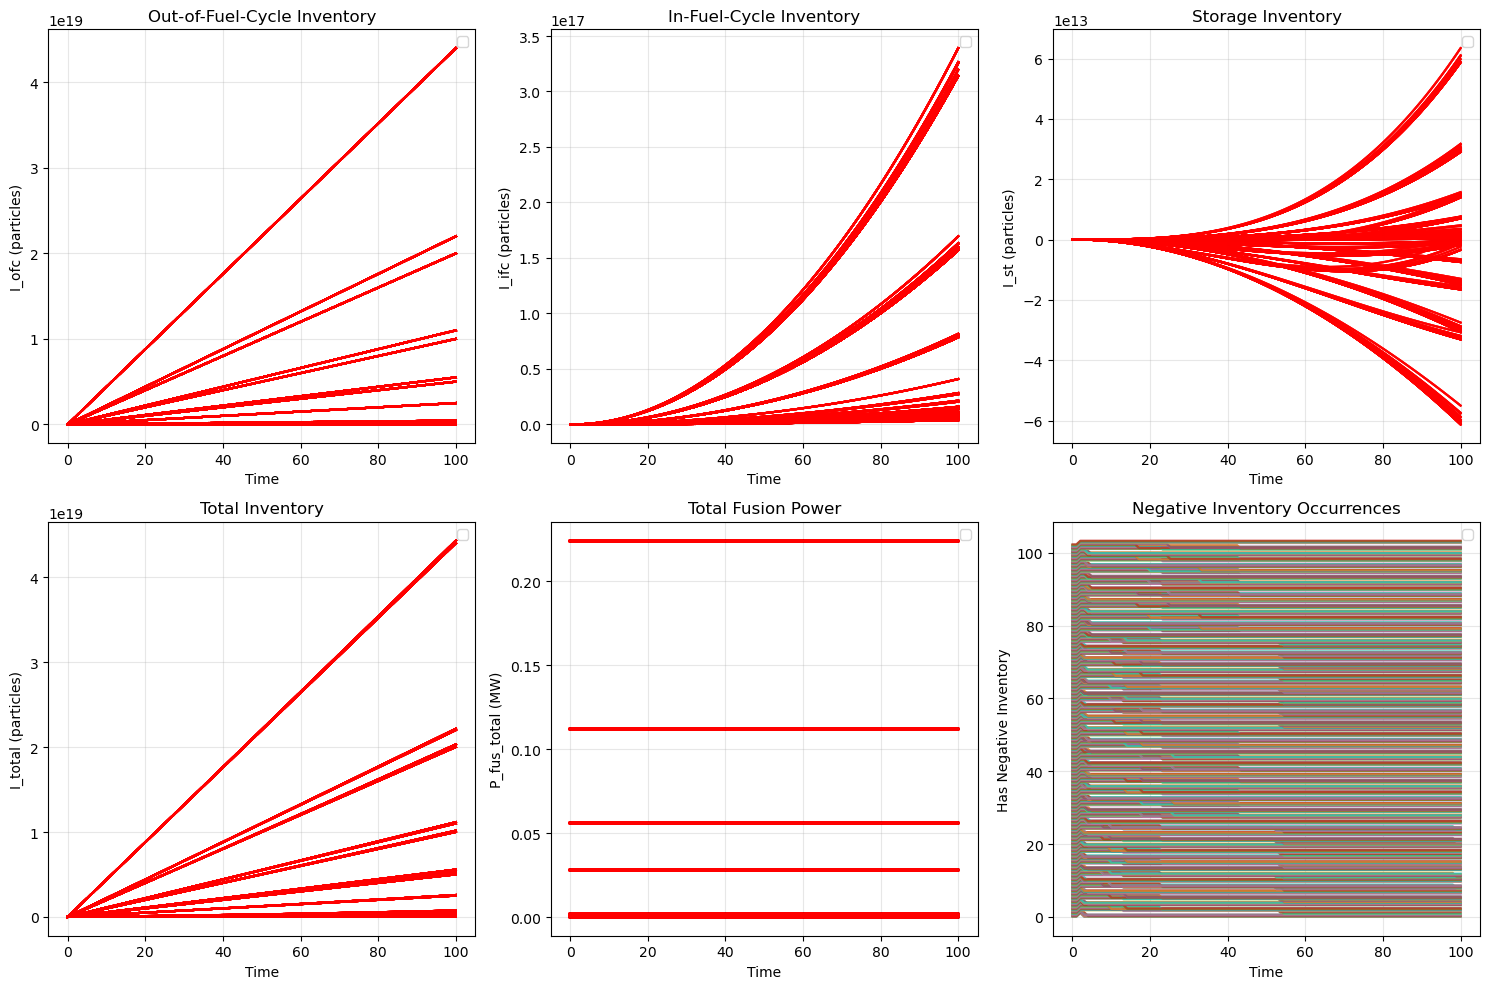

In [4]:
# Plot inventories
plt.figure(figsize=(15, 10))

# Plot 1: OFC Inventory
plt.subplot(2, 3, 1)
for i in range(results["I_ofc"].shape[0]):
    color = 'red' if np.any(results["negative_inventory"][i, :]) else 'blue'
    plt.plot(times, results["I_ofc"][i], color=color,alpha=0.7)
plt.xlabel("Time")
plt.ylabel("I_ofc (particles)")
plt.title("Out-of-Fuel-Cycle Inventory")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: IFC Inventory
plt.subplot(2, 3, 2)
for i in range(results["I_ifc"].shape[0]):
    color = 'red' if np.any(results["negative_inventory"][i, :]) else 'blue'
    plt.plot(times, results["I_ifc"][i], color=color, alpha=0.7)
plt.xlabel("Time")
plt.ylabel("I_ifc (particles)")
plt.title("In-Fuel-Cycle Inventory")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 3: Storage Inventory
plt.subplot(2, 3, 3)
for i in range(results["I_st"].shape[0]):
    color = 'red' if np.any(results["negative_inventory"][i, :]) else 'blue'
    plt.plot(times, results["I_st"][i], color=color, alpha=0.7)
plt.xlabel("Time")
plt.ylabel("I_st (particles)")
plt.title("Storage Inventory")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 4: Total Inventory
plt.subplot(2, 3, 4)
I_total = results["I_ofc"] + results["I_ifc"] + results["I_st"]
for i in range(I_total.shape[0]):
    color = 'red' if np.any(results["negative_inventory"][i, :]) else 'blue'
    plt.plot(times, I_total[i], color=color, alpha=0.7)
plt.xlabel("Time")
plt.ylabel("I_total (particles)")
plt.title("Total Inventory")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 5: Fusion Power for comparison
plt.subplot(2, 3, 5)
for i in range(results["P_fus_total"].shape[0]):
    color = 'red' if np.any(results["negative_inventory"][i, :]) else 'blue'
    plt.plot(times, results["P_fus_total"][i] / 1e6, color=color, alpha=0.7)  # Convert to MW
plt.xlabel("Time")
plt.ylabel("P_fus_total (MW)")
plt.title("Total Fusion Power")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 6: Negative inventory mask
plt.subplot(2, 3, 6)
for i in range(results["negative_inventory"].shape[0]):
    plt.plot(times, results["negative_inventory"][i].astype(int) + i*0.1, 
             alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Has Negative Inventory")
plt.title("Negative Inventory Occurrences")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
# Print summary statistics
print("=== INVENTORY ANALYSIS SUMMARY ===")
print(f"Total number of parameter combinations: {results['I_ofc'].shape[0]}")
print()

successful_cases = []
unsuccessful_cases = []

for i in range(results["I_ofc"].shape[0]):
    has_negative = np.any(results["negative_inventory"][i, :])
    min_ofc = np.min(results["I_ofc"][i, :])
    min_ifc = np.min(results["I_ifc"][i, :])
    min_st = np.min(results["I_st"][i, :])
    
    case_info = {
        'case_num': i+1,
        'min_ofc': min_ofc,
        'min_ifc': min_ifc,
        'min_st': min_st,
        'has_negative': has_negative
    }
    
    if not has_negative:
        successful_cases.append(case_info)
    else:
        unsuccessful_cases.append(case_info)

# Print successful cases
if successful_cases:
    print("=== SUCCESSFUL CASES (No Negative Inventories) ===")
    for case in successful_cases:
        print(f"Case {case['case_num']}:")
        print(f"  Min OFC inventory: {case['min_ofc']:.2e}")
        print(f"  Min IFC inventory: {case['min_ifc']:.2e}")
        print(f"  Min Storage inventory: {case['min_st']:.2e}")
        print()
else:
    print("=== NO SUCCESSFUL CASES FOUND ===")
    print()

# Print unsuccessful cases
if unsuccessful_cases:
    print("=== UNSUCCESSFUL CASES (Has Negative Inventories) ===")
    for case in unsuccessful_cases:
        print(f"Case {case['case_num']}:")
        print(f"  Min OFC inventory: {case['min_ofc']:.2e}")
        print(f"  Min IFC inventory: {case['min_ifc']:.2e}")
        print(f"  Min Storage inventory: {case['min_st']:.2e}")
        print()
else:
    print("=== ALL CASES SUCCESSFUL ===")
    print()

# Summary statistics
print("=== OVERALL SUMMARY ===")
print(f"Successful cases: {len(successful_cases)}/{results['I_ofc'].shape[0]} ({len(successful_cases)/results['I_ofc'].shape[0]*100:.1f}%)")
print(f"Unsuccessful cases: {len(unsuccessful_cases)}/{results['I_ofc'].shape[0]} ({len(unsuccessful_cases)/results['I_ofc'].shape[0]*100:.1f}%)")

if successful_cases:
    # Find the best case (highest minimum storage inventory)
    best_case = max(successful_cases, key=lambda x: x['min_st'])
    print(f"Best case (highest min storage): Case {best_case['case_num']} with min storage = {best_case['min_st']:.2e}")

if unsuccessful_cases:
    # Find the least problematic case (highest minimum among negative cases)
    least_bad_case = max(unsuccessful_cases, key=lambda x: min(x['min_ofc'], x['min_ifc'], x['min_st']))
    min_val = min(least_bad_case['min_ofc'], least_bad_case['min_ifc'], least_bad_case['min_st'])
    print(f"Least problematic case: Case {least_bad_case['case_num']} with minimum value = {min_val:.2e}")

=== INVENTORY ANALYSIS SUMMARY ===
Total number of parameter combinations: 1024

=== NO SUCCESSFUL CASES FOUND ===

=== UNSUCCESSFUL CASES (Has Negative Inventories) ===
Case 1:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -1.62e+07

Case 2:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -1.62e+07

Case 3:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -6.47e+07

Case 4:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -6.47e+07

Case 5:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -1.62e+07

Case 6:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -1.62e+07

Case 7:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -6.47e+07

Case 8:
  Min OFC inventory: 0.00e+00
  Min IFC inventory: 0.00e+00
  Min Storage inventory: -6.47e+07